In [12]:
import os
import xarray as xr
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# 加载 xarray 文件
file_path = "/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex61_onestepdiffusion_dividemax_minmaxnormlazie_timesteps250_l2_droptop_0.5_150epoch/prcp_downs_diffusion_year_2020.nc"  # 替换为实际路径
data = xr.open_dataset(file_path)

# 提取 fcst 和 hr
fcst = data['fcst'].values  # 预测降雨
hr = data['hr'].values  # 真实降雨

# 初始化一个新数组用于存储校正后的预测值
fcst_corrected = np.zeros_like(fcst)

# 方法一：逐时间步线性回归改进
for t in range(fcst.shape[0]):
    print(f"Processing time step {t+1}/{fcst.shape[0]}...")
    
    # 提取当前时间步的 fcst 和 hr
    fcst_t = fcst[t]
    hr_t = hr[t]
    
    # 筛选非零值（预测值为零的区域不需要校正）
    mask = fcst_t > 0
    fcst_nonzero = fcst_t[mask]
    hr_nonzero = hr_t[mask]

    # 如果没有非零值，跳过校正
    if len(fcst_nonzero) == 0:
        fcst_corrected[t] = fcst_t
        continue

    # 初次线性回归拟合（无截距模型 y = kx）
    model = LinearRegression(fit_intercept=False)
    model.fit(fcst_nonzero.reshape(-1, 1), hr_nonzero)
    k = model.coef_[0]
    
    # 如果 k <= 0，则选择一个候选正值 k 进行拟合
    if k <= 0:
        candidate_k = np.linspace(0.01, 80, 200)  # 候选 k 值范围
        best_k, min_error = 0, float('inf')
        for k_candidate in candidate_k:
            predicted = k_candidate * fcst_nonzero
            error = np.mean((predicted - hr_nonzero) ** 2)  # 均方误差
            if error < min_error:
                best_k, min_error = k_candidate, error
        k = best_k
    print(f"Time step {t}: k = {k:.4f}")

    # 对所有时间点的非零值应用线性变换
    fcst_corrected_t = np.copy(fcst_t)
    fcst_corrected_t[mask] = k * fcst_nonzero

    # 确保校正后的值非负
    fcst_corrected_t[fcst_corrected_t < 0] = 0

    # 保存校正结果
    fcst_corrected[t] = fcst_corrected_t

# 更新 xarray 数据集
data['fcst_corrected'] = (("time", "lat", "lon"), fcst_corrected)

output_dir = os.path.dirname(file_path)
corrected_file_path = os.path.join(output_dir, "corrected_prcp_downs_timelinear.nc")
data.to_netcdf(corrected_file_path)

print(f"Corrected data saved to {corrected_file_path}")



Processing time step 1/6912...
Time step 0: k = 17.6795
Processing time step 2/6912...
Time step 1: k = 0.4503
Processing time step 3/6912...
Time step 2: k = 29.1203
Processing time step 4/6912...
Time step 3: k = 0.9418
Processing time step 5/6912...
Time step 4: k = 40.4543
Processing time step 6/6912...
Time step 5: k = 12.1817
Processing time step 7/6912...
Time step 6: k = 0.1849
Processing time step 8/6912...
Time step 7: k = 53.3911
Processing time step 9/6912...
Time step 8: k = 42.3158
Processing time step 10/6912...
Time step 9: k = 25.6785
Processing time step 11/6912...
Time step 10: k = 0.2396
Processing time step 12/6912...
Time step 11: k = 0.6531
Processing time step 13/6912...
Time step 12: k = 35.7155
Processing time step 14/6912...
Time step 13: k = 38.5820
Processing time step 15/6912...
Time step 14: k = 34.4789
Processing time step 16/6912...
Time step 15: k = 2.1394
Processing time step 17/6912...
Time step 16: k = 0.3662
Processing time step 18/6912...
Time ste

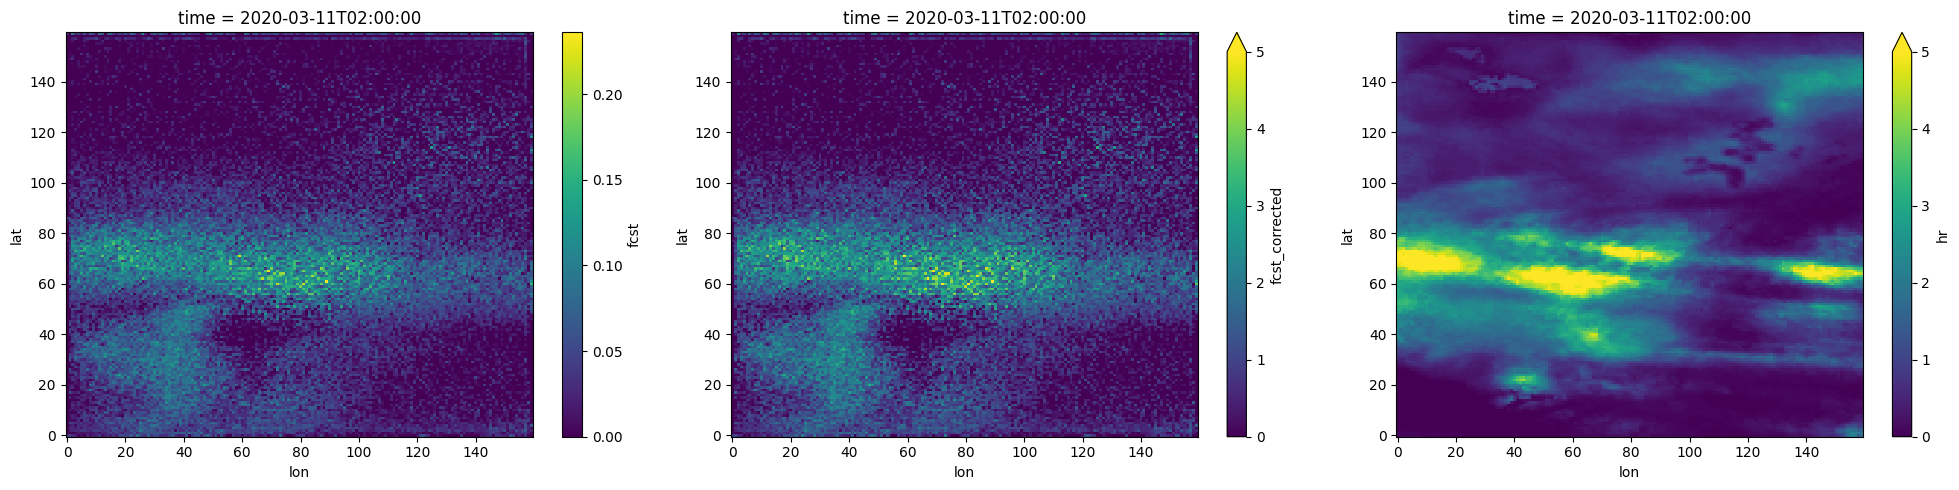

In [16]:
import os
import xarray as xr
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
data = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex61_onestepdiffusion_dividemax_minmaxnormlazie_timesteps250_l2_droptop_0.5_150epoch/corrected_prcp_downs_timelinear.nc")
time_index = 2421  
plt.figure(figsize=(20, 5))

# 原始预测雨图
plt.subplot(1, 3, 1)
plt.title("Original FCST")
data['fcst'].isel(time=time_index).plot()

# 校正后的雨图
plt.subplot(1, 3, 2)
plt.title("Corrected FCST")
data['fcst_corrected'].isel(time=time_index).plot(vmin=0, vmax=5)

# 真实降雨雷达图
plt.subplot(1, 3, 3)
plt.title("Ground Truth (HR)")
data['hr'].isel(time=time_index).plot(vmin=0, vmax=5)

plt.tight_layout()
plt.show()

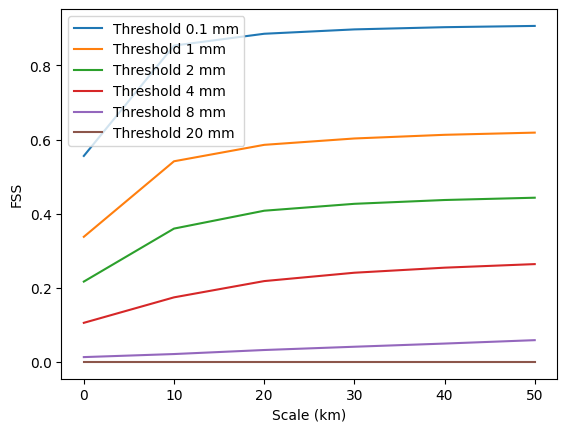

In [14]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss
# 提取数据
y_pred_np = data['fcst_corrected'].values
tar_np = data['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()

In [17]:
import os
import xarray as xr
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# 加载 xarray 文件
file_path = "/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex61_onestepdiffusion_dividemax_minmaxnormlazie_timesteps250_l2_droptop_0.5_150epoch/prcp_downs_diffusion_year_2020.nc"
precip_data = xr.open_dataset(file_path)

# 提取 fcst 和 hr
fcst = precip_data['fcst'].values  # 预测降雨 (time, lat, lon)
hr = precip_data['hr'].values  # 真实降雨 (time, lat, lon)

# 初始化一个新数组用于存储校正后的预测值
fcst_corrected = np.zeros_like(fcst)

# 获取时间、纬度和经度的维度大小
time_dim, lat_dim, lon_dim = fcst.shape

# 遍历每个像素点（lat, lon）
for lat in range(lat_dim):
    for lon in range(lon_dim):
        print(f"Processing pixel ({lat+1}/{lat_dim}, {lon+1}/{lon_dim})...")

        # 提取当前像素点的时间序列
        fcst_pixel = fcst[:, lat, lon]  # (time,)
        hr_pixel = hr[:, lat, lon]  # (time,)

        # 筛选非零值（预测值为零的时间点不需要校正）
        mask = fcst_pixel > 0
        fcst_nonzero = fcst_pixel[mask]
        hr_nonzero = hr_pixel[mask]

        # 如果没有非零值，跳过校正
        if len(fcst_nonzero) == 0:
            fcst_corrected[:, lat, lon] = fcst_pixel
            continue

        # 线性回归拟合（y = kx + b）
        model = LinearRegression()
        model.fit(fcst_nonzero.reshape(-1, 1), hr_nonzero)
        k, b = model.coef_[0], model.intercept_
        print(f"Pixel ({lat}, {lon}): k = {k:.4f}, b = {b:.4f}")

        # 对所有时间点的非零值应用线性变换
        fcst_corrected_pixel = np.copy(fcst_pixel)
        fcst_corrected_pixel[mask] = k * fcst_nonzero + b

        # 确保校正后的值非负
        fcst_corrected_pixel[fcst_corrected_pixel < 0] = 0

        # 保存校正结果
        fcst_corrected[:, lat, lon] = fcst_corrected_pixel

# 更新 xarray 数据集
precip_data['fcst_corrected'] = (("time", "lat", "lon"), fcst_corrected)

# 保存校正后的数据到与 file_path 相同的目录下
output_dir = os.path.dirname(file_path)
corrected_file_path = os.path.join(output_dir, "corrected_prcp_downs_pixelwise.nc")
precip_data.to_netcdf(corrected_file_path)

print(f"Corrected data saved to {corrected_file_path}")

Processing pixel (1/160, 1/160)...
Pixel (0, 0): k = -0.9868, b = 0.4720
Processing pixel (1/160, 2/160)...
Pixel (0, 1): k = -0.0258, b = 0.3784
Processing pixel (1/160, 3/160)...
Pixel (0, 2): k = -0.7716, b = 0.4514
Processing pixel (1/160, 4/160)...
Pixel (0, 3): k = -0.7039, b = 0.4472
Processing pixel (1/160, 5/160)...
Pixel (0, 4): k = -0.4269, b = 0.4318
Processing pixel (1/160, 6/160)...
Pixel (0, 5): k = -0.4375, b = 0.4325
Processing pixel (1/160, 7/160)...
Pixel (0, 6): k = -0.2651, b = 0.4135
Processing pixel (1/160, 8/160)...
Pixel (0, 7): k = -0.3122, b = 0.4199
Processing pixel (1/160, 9/160)...
Pixel (0, 8): k = -0.2570, b = 0.4210
Processing pixel (1/160, 10/160)...
Pixel (0, 9): k = -0.4260, b = 0.4368
Processing pixel (1/160, 11/160)...
Pixel (0, 10): k = -0.3606, b = 0.4237
Processing pixel (1/160, 12/160)...
Pixel (0, 11): k = -0.4429, b = 0.4286
Processing pixel (1/160, 13/160)...
Pixel (0, 12): k = -0.3537, b = 0.4128
Processing pixel (1/160, 14/160)...
Pixel (0

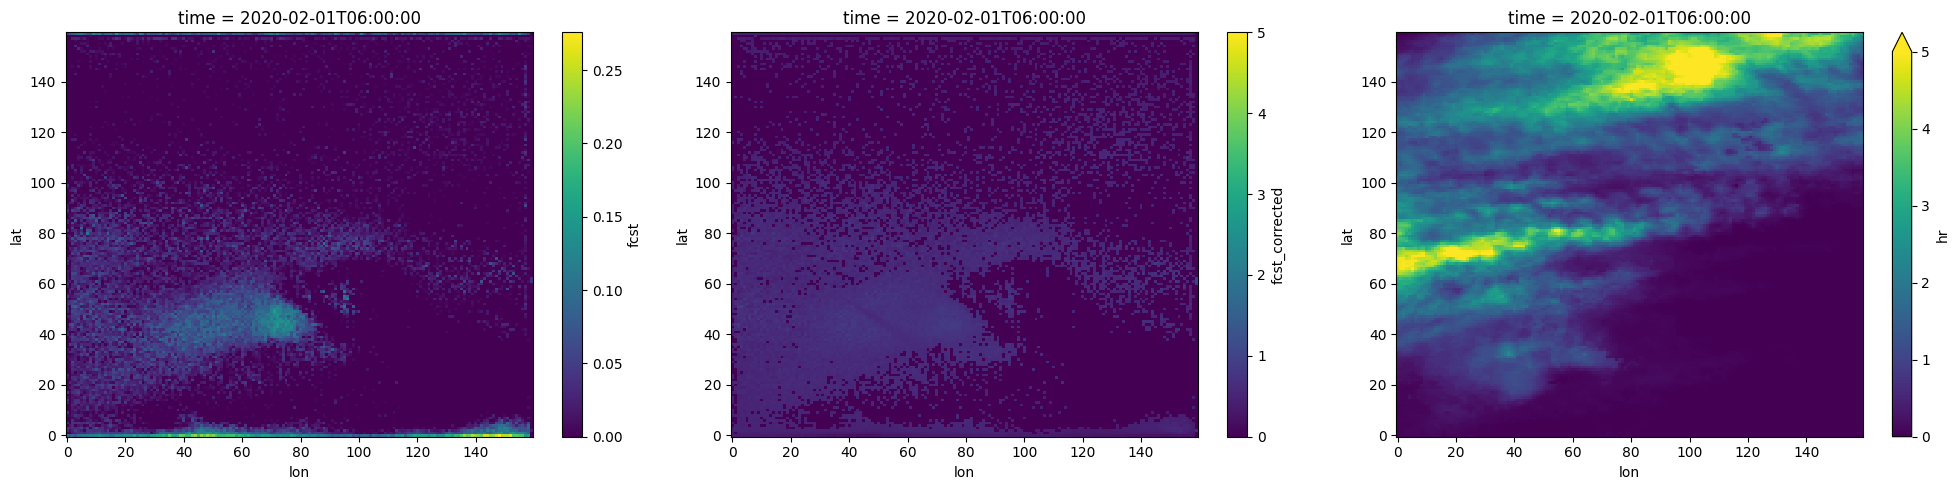

In [22]:
time_index = 0 
plt.figure(figsize=(20, 5))

# 原始预测雨图
plt.subplot(1, 3, 1)
plt.title("Original FCST")
precip_data['fcst'].isel(time=time_index).plot()

# 校正后的雨图
plt.subplot(1, 3, 2)
plt.title("Corrected FCST")
precip_data['fcst_corrected'].isel(time=time_index).plot(vmin=0, vmax=5)

# 真实降雨雷达图
plt.subplot(1, 3, 3)
plt.title("Ground Truth (HR)")
precip_data['hr'].isel(time=time_index).plot(vmin=0, vmax=5)

plt.tight_layout()
plt.show()